# 5. Iterative Modeling

In [ ]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

    print(f"Accuracy: {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1 Score: {f1:.3f}")
    print(f"ROC AUC: {roc_auc:.3f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("-"*20)

    return accuracy, precision, recall, f1, roc_auc

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
import xgboost as xgb

# dictionary of models
models = {
    "Logistic Regression": LogisticRegression(solver='liblinear'),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric='logloss')
}

results = {}
for model_name, model in models.items():
    print(f"Evaluating {model_name}:")
    # Fit the model before evaluating
    model.fit(X_train, y_train)
    metrics = evaluate_model(model, X_test, y_test)
    results[model_name] = metrics

Evaluating Logistic Regression:
Accuracy: 0.930
Precision: 0.927
Recall: 0.932
F1 Score: 0.929
ROC AUC: 0.978
Confusion Matrix:
 [[1074   83]
 [  77 1052]]
--------------------
Evaluating Decision Tree:
Accuracy: 0.932
Precision: 0.932
Recall: 0.931
F1 Score: 0.931
ROC AUC: 0.932
Confusion Matrix:
 [[1080   77]
 [  78 1051]]
--------------------
Evaluating Random Forest:
Accuracy: 0.958
Precision: 0.962
Recall: 0.954
F1 Score: 0.958
ROC AUC: 0.990
Confusion Matrix:
 [[1114   43]
 [  52 1077]]
--------------------
Evaluating Gradient Boosting:
Accuracy: 0.950
Precision: 0.947
Recall: 0.952
F1 Score: 0.950
ROC AUC: 0.989
Confusion Matrix:
 [[1097   60]
 [  54 1075]]
--------------------
Evaluating SVM:
Accuracy: 0.941
Precision: 0.941
Recall: 0.938
F1 Score: 0.940
ROC AUC: 0.983
Confusion Matrix:
 [[1091   66]
 [  70 1059]]
--------------------
Evaluating XGBoost:
Accuracy: 0.959
Precision: 0.959
Recall: 0.957
F1 Score: 0.958
ROC AUC: 0.991
Confusion Matrix:
 [[1111   46]
 [  48 1081]]
-

In [ ]:
# Table of all metrics for all models
metrics_data = [list(metrics) for metrics in results.values()]
model_names = list(results.keys())
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']

all_metrics_df = pd.DataFrame(metrics_data, index=model_names, columns=metric_names)
styled_all_metrics_df = all_metrics_df.style.set_properties(**{'text-align': 'center'}) \
                                            .format("{:.3f}") \
                                            .set_caption("Model Performance Metrics")
display(styled_all_metrics_df)

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.930,0.927,0.932,0.929,0.978
Decision Tree,0.932,0.932,0.931,0.931,0.932
Random Forest,0.958,0.962,0.954,0.958,0.990
Gradient Boosting,0.950,0.947,0.952,0.950,0.989
SVM,0.941,0.941,0.938,0.940,0.983
XGBoost,0.959,0.959,0.957,0.958,0.991


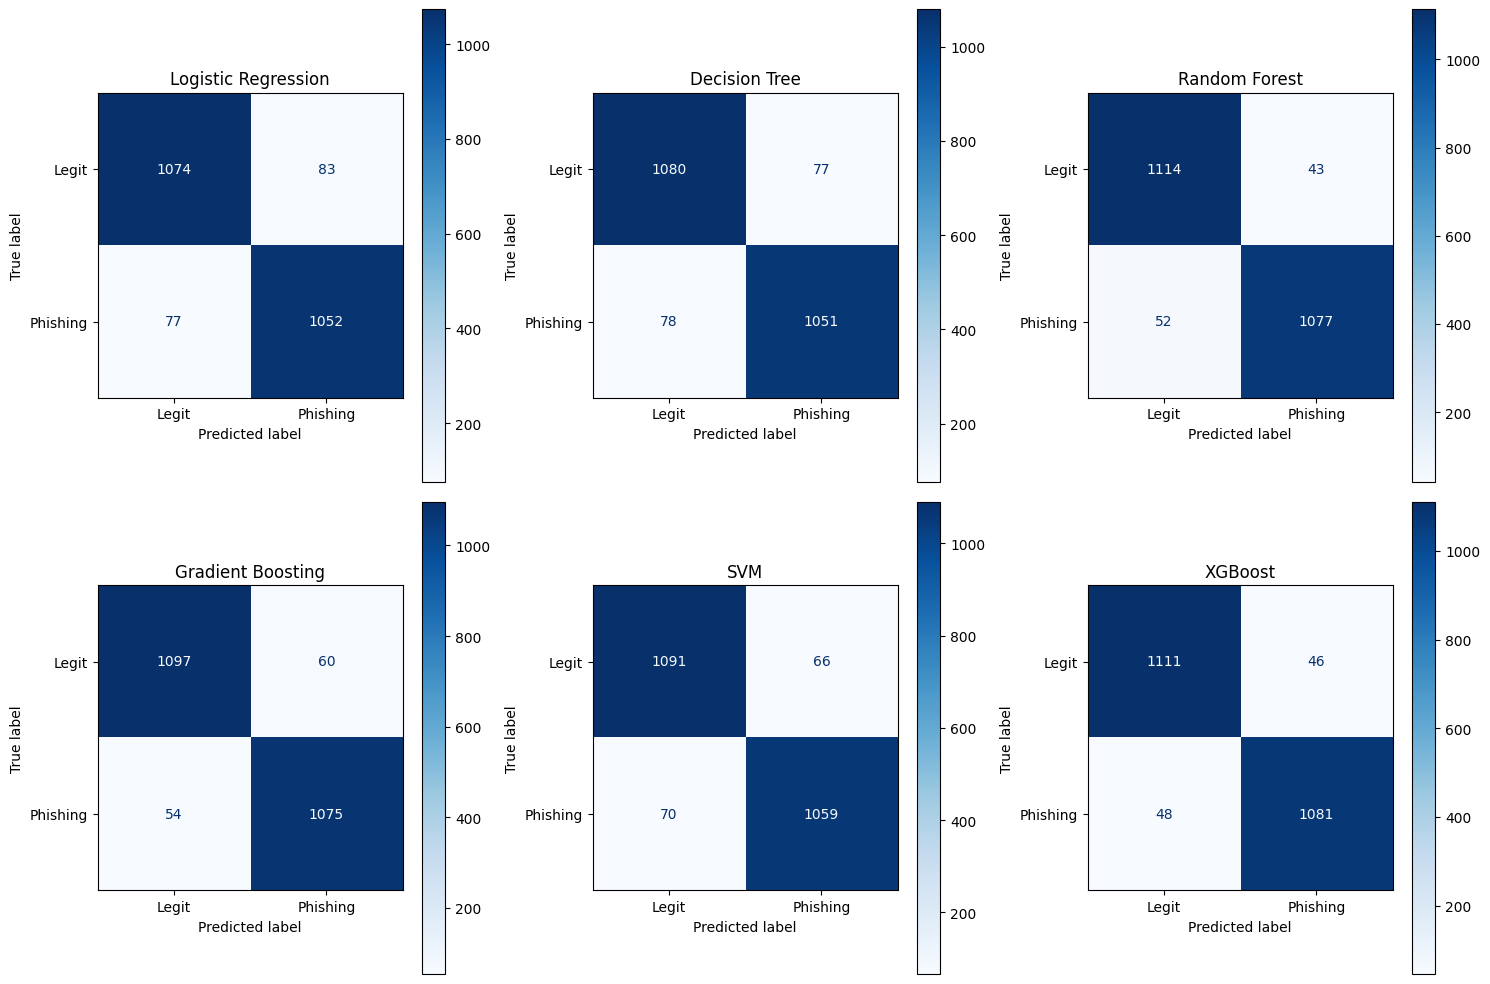

In [ ]:
# Visual of confusion matrix for all models
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, (model_name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Phishing'])
    disp.plot(ax=axes[i], cmap=plt.cm.Blues)
    axes[i].set_title(model_name)

plt.tight_layout()
plt.show()

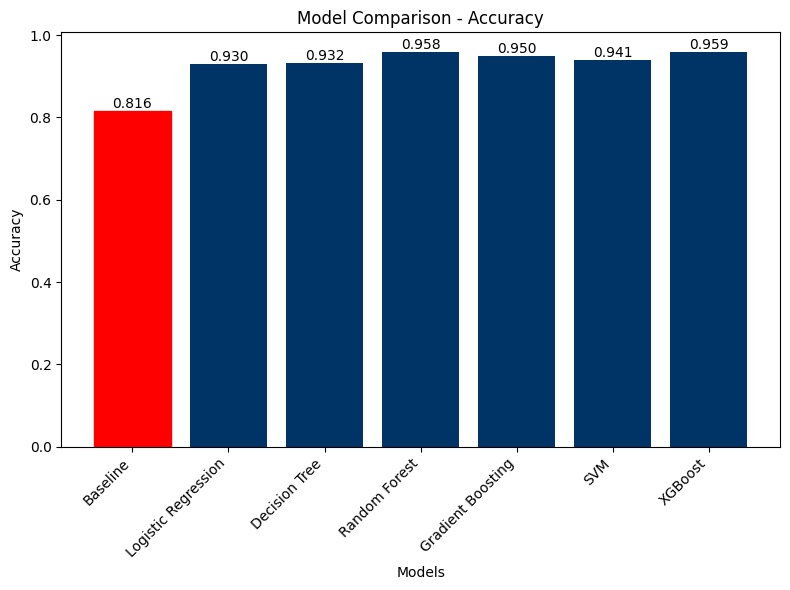

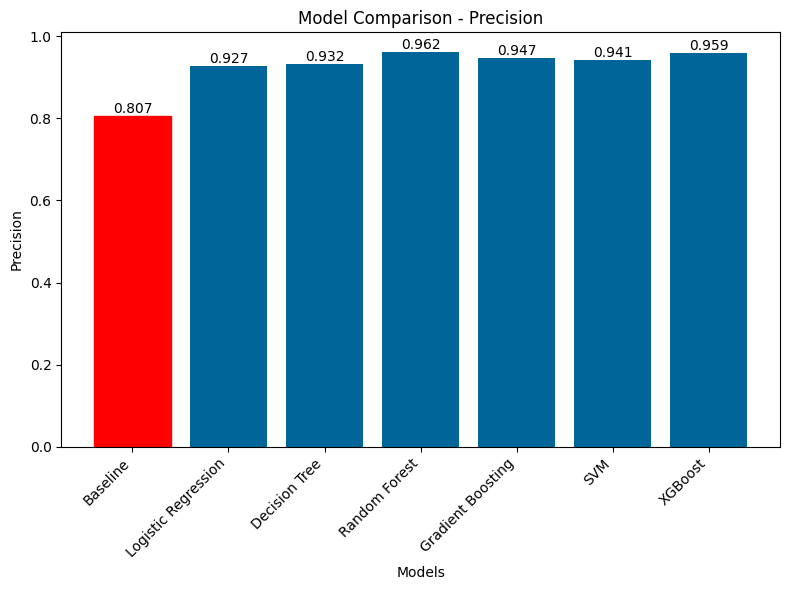

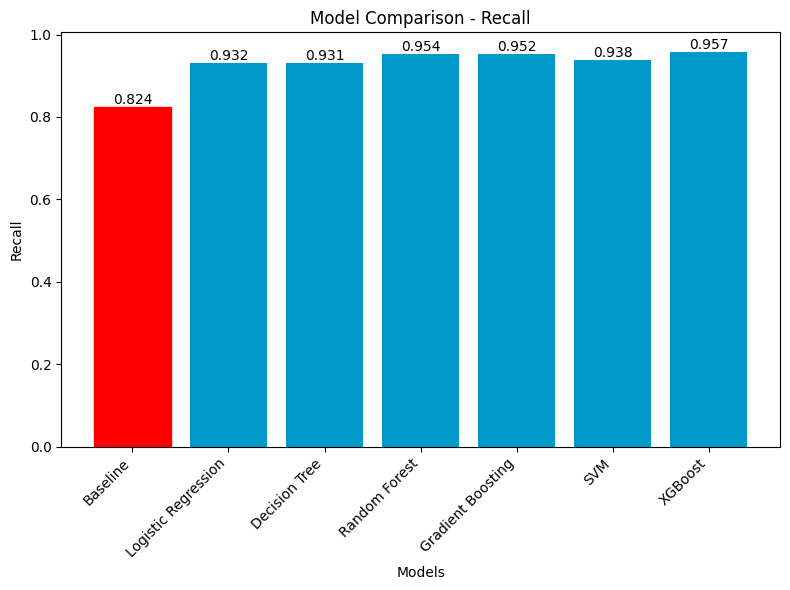

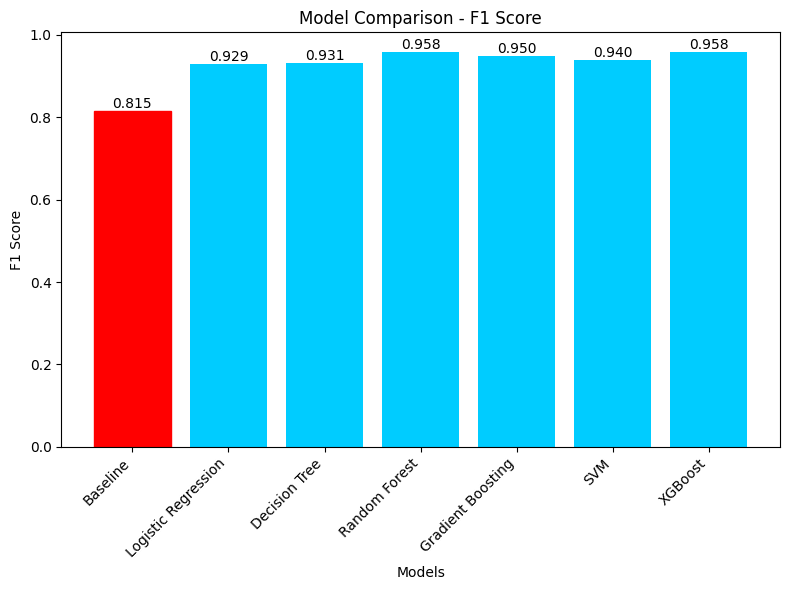

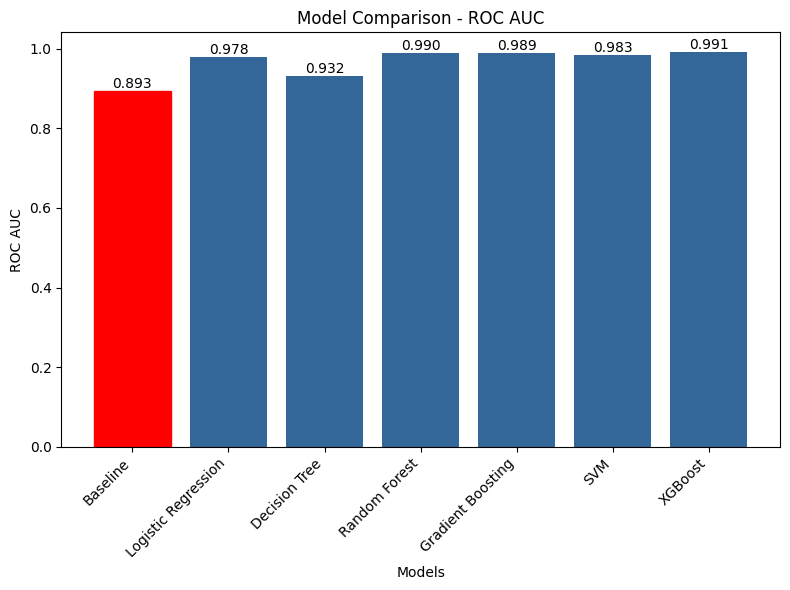

In [ ]:
# Extract metrics and model names from results dictionary
metrics_data = [list(metrics) for metrics in results.values()]
model_names = list(results.keys())
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']

# Baseline model's metrics
baseline_metrics = [0.816, 0.807, 0.824, 0.815, 0.893]

model_names.insert(0, 'Baseline')
metrics_data.insert(0, baseline_metrics)
colors = ['#003366', '#006699', '#0099CC', '#00CCFF', '#336699']

for i, metric_name in enumerate(metric_names):
    fig, ax = plt.subplots(figsize=(8, 6))
    all_bars = ax.bar(model_names, [metrics[i] for metrics in metrics_data], color=colors[i % len(colors)])  # Loop colors if needed
    all_bars[0].set_color('red')
    for bar in all_bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.3f}',
                ha='center', va='bottom')

    ax.set_xlabel('Models')
    ax.set_ylabel(metric_name)
    ax.set_title(f'Model Comparison - {metric_name}')
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

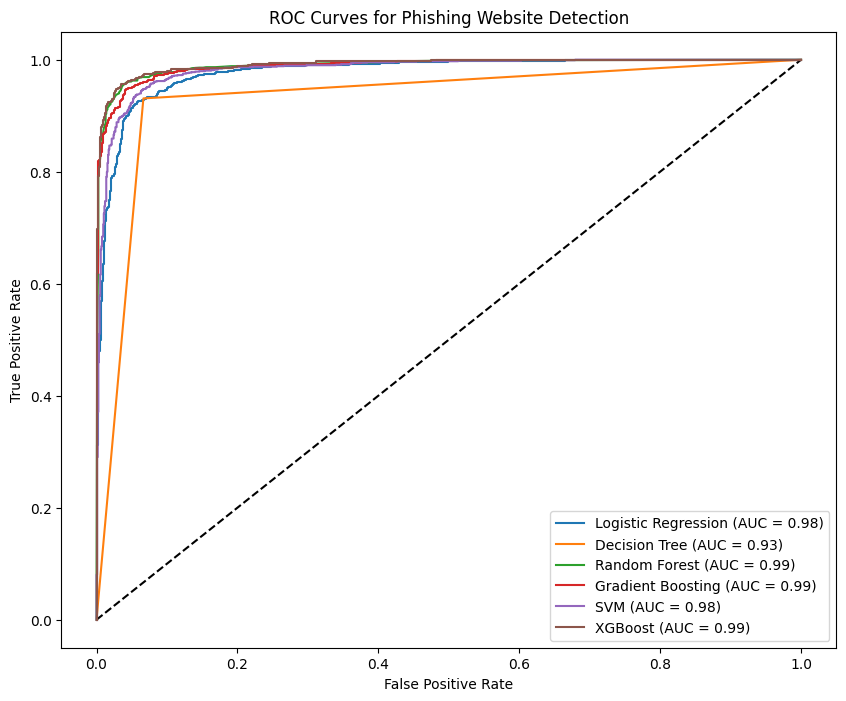

In [ ]:
# Plot roc curves for comparison
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random classifier

for model_name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability of class 1
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Phishing Website Detection')
plt.legend(loc='lower right')
plt.show()

Interpretation after Data preprocessing and training----

All the models performed relatively well and high. Compared to the basline model the logistic regression model did significantly improve for all the metrics as well as in the confusion matrix. The incorrect number of outputs it produced went down by more than half and it had a higher intepretation of the TN/TP's.

The Random Forest and XGBoost model performed the best out of all the models as they had the highest output for all the metrics and the best confusion matrices, so they will be used for hyperparameter tuning and one will ultimately be chosen as the best performing model.



 In order to determine the best performing model I will be using the F1 score metric. The F1 score is a valuable metric because it balances the need to correctly identify phishing websites (recall) with the need to avoid misclassifying legitimate websites as phishing (precision). Having a high F1 score would indiacate that the model has both high precision and high recall, meaning it is good at identifying positive instances and avoiding false positives, whcih basically means that the model is effective at both catching phishing websites and minimizing false alarms.

In [ ]:
# 2. Model parameter tuning

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

param_grid_rf = {
    'n_estimators': [98, 100, 99],
    'max_depth': [None, 5, 1],
    'min_samples_split': [4, 5, 6],
    'min_samples_leaf': [1, 2,5],
}

param_grid_xgb = {
    'n_estimators': [300, 302, 301],
    'learning_rate': [0.049, 0.055, 0.05],
    'max_depth': [10, 9, 8],
    'subsample': [1, None, .09],
}

grid_search_rf = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
        param_grid=param_grid_rf,
        scoring='f1',
        cv=5,
        n_jobs=-1,
        verbose=2)
grid_search_rf.fit(X_train, y_train)

grid_search_xgb = GridSearchCV(estimator=xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
        param_grid=param_grid_xgb,
        scoring='f1',
        cv=5,
        n_jobs=-1,
        verbose=2)
grid_search_xgb.fit(X_train, y_train)

print("\nBest parameters for Random Forest:", grid_search_rf.best_params_)
evaluate_model(grid_search_rf.best_estimator_, X_test, y_test)
print("\nBest parameters for XGBoost:", grid_search_xgb.best_params_)
evaluate_model(grid_search_xgb.best_estimator_, X_test, y_test)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 99}
Accuracy: 0.954
Precision: 0.956
Recall: 0.950
F1 Score: 0.953
ROC AUC: 0.990
Confusion Matrix:
 [[1108   49]
 [  56 1073]]
--------------------

Best parameters for XGBoost: {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 301, 'subsample': 1}
Accuracy: 0.961
Precision: 0.965
Recall: 0.956
F1 Score: 0.960
ROC AUC: 0.992
Confusion Matrix:
 [[1118   39]
 [  50 1079]]
--------------------


(0.9610673665791776,
 0.9651162790697675,
 0.9557130203720107,
 0.9603916332888296,
 np.float64(0.9917558084077128))

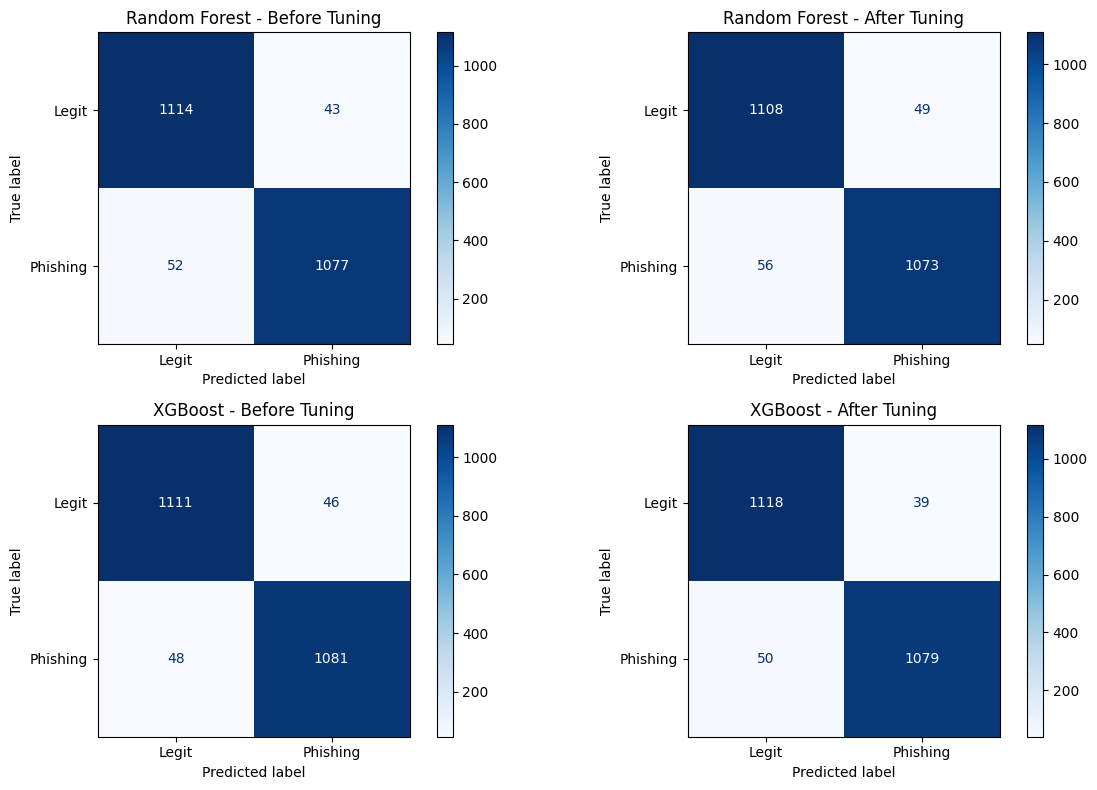

In [ ]:
# Visual of confusion matrices
def format_confusion_matrix(cm):
    return

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

# format confusion matrices
cm_rf_before = confusion_matrix(y_test, models['Random Forest'].predict(X_test))
cm_rf_after = confusion_matrix(y_test, grid_search_rf.best_estimator_.predict(X_test))
cm_xgb_before = confusion_matrix(y_test, models['XGBoost'].predict(X_test))
cm_xgb_after = confusion_matrix(y_test, grid_search_xgb.best_estimator_.predict(X_test))

cm_rf_before_formatted = format_confusion_matrix(cm_rf_before)
cm_rf_after_formatted = format_confusion_matrix(cm_rf_after)
cm_xgb_before_formatted = format_confusion_matrix(cm_xgb_before)
cm_xgb_after_formatted = format_confusion_matrix(cm_xgb_after)

# Random Forest - Before Tuning
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf_before, display_labels=['Legit', 'Phishing'])
disp.plot(ax=axes[0], cmap=plt.cm.Blues)
axes[0].set_title("Random Forest - Before Tuning")

# Random Forest - After Tuning
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf_after, display_labels=['Legit', 'Phishing'])
disp.plot(ax=axes[1], cmap=plt.cm.Blues)
axes[1].set_title("Random Forest - After Tuning")

# XGBoost - Before Tuning
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_before, display_labels=['Legit', 'Phishing'])
disp.plot(ax=axes[2], cmap=plt.cm.Blues)
axes[2].set_title("XGBoost - Before Tuning")

# XGBoost - After Tuning
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_after, display_labels=['Legit', 'Phishing'])
disp.plot(ax=axes[3], cmap=plt.cm.Blues)
axes[3].set_title("XGBoost - After Tuning")

plt.tight_layout()
plt.show()

Reasoning for parameter chosen----

Random Forest is an ensemble method based on decision trees. It works by building multiple decision trees and aggregating their predictions. Some of its key hyperparameters include:
- n_estimators: The number of decision trees in the forest.
- max_depth: The maximum depth of each tree.
- min_samples_split: The minimum number of samples required to split an internal node.
- min_samples_leaf: The minimum number of samples required to be at a leaf node.

XGBoost is a gradient boosting algorithm that builds an ensemble of weak learners (typically decision trees). It focuses on minimizing a loss function by iteratively adding new trees that correct the errors of previous trees. Some of its key hyperparameters are:
- n_estimators: The number of boosting rounds (trees).
- learning_rate: The step size shrinkage used in update to prevents overfitting.
- max_depth: The maximum depth of each tree.
- subsample: The fraction of samples used for fitting each tree.

In [ ]:
# More Tuning for XGBoost
param_grid_xgb = {
    'n_estimators': [300, 299],
    'learning_rate': [.0469, 0.047],
    'max_depth': [10, 11],
    'subsample': [.779, .78],
    'colsample_bytree': [.5],
    'gamma': [.099, .01],
}

grid_search_xgb = GridSearchCV(estimator=xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
        param_grid=param_grid_xgb,
        scoring='f1',
        cv=5,
        n_jobs=-1,
        verbose=2)
grid_search_xgb.fit(X_train, y_train)

print("\nBest parameters for XGBoost:", grid_search_xgb.best_params_)
evaluate_model(grid_search_xgb.best_estimator_, X_test, y_test)

Fitting 5 folds for each of 32 candidates, totalling 160 fits

Best parameters for XGBoost: {'colsample_bytree': 0.5, 'gamma': 0.01, 'learning_rate': 0.0469, 'max_depth': 11, 'n_estimators': 300, 'subsample': 0.779}
Accuracy: 0.961
Precision: 0.960
Recall: 0.961
F1 Score: 0.961
ROC AUC: 0.992
Confusion Matrix:
 [[1112   45]
 [  44 1085]]
--------------------


(0.9610673665791776,
 0.9601769911504425,
 0.9610274579273693,
 0.9606020362992475,
 np.float64(0.99242566332862))

After tuning it was found that XGBoost was the better model with an F1 score of 0.961 and if we were to add more parameters it would give us a higher F1 score. The confusion matrix also improved slightly from the first XGBoost model.